# DESI BGS FRACCOV

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

In [3]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-bright.fits"

#Reading file:
DR1 = Table.read(FILE_DR1)
col_ipix = f'HealPIX_{nside}'
DR1[col_ipix] = hp.ang2pix(nside, DR1['RA'], DR1['DEC'], nest=True, lonlat=True)
DR1

HPXPIXEL,RA,DEC,TILEIDS,EXPFACS,NPASS,EXPFAC_MEAN,NTILE,FRACCOV,HealPIX_128
int64,float64,float64,int64[4],float64[4],int64,float64,float64,float64,int64
0,45.0,0.03730194242227469,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
1,45.04394531249999,0.07460390065516265,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
2,44.9560546875,0.07460390065516265,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
3,45.0,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
4,45.08789062499999,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
5,45.13183593749999,0.14920792779581404,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
6,45.04394531249999,0.14920792779581404,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
7,45.08789062499999,0.18651002832535823,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0
8,44.912109375,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25,0


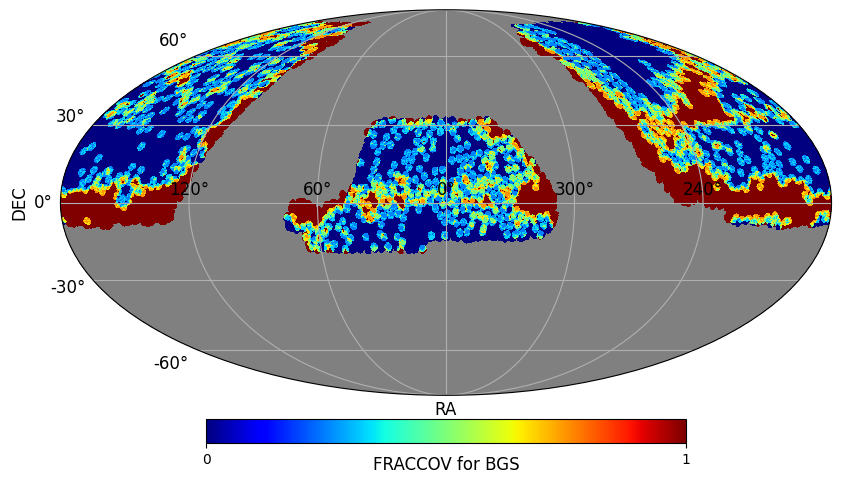

In [4]:
hp.projview(DR1['FRACCOV'], unit="FRACCOV for BGS", nest=True, graticule=True, graticule_labels=True, cmap='jet')
plt.xlabel("RA")
plt.ylabel("DEC");
#plt.savefig(DIR + "DESI Figures/DESI_DR1_completness_map.pdf", bbox_inches='tight');

## Density

In [5]:
#File names:
FILE_NGC = DIR + "BGS_ANY_NGC_clustering.dat.fits"
FILE_SGC = DIR + "BGS_ANY_SGC_clustering.dat.fits"

#Reading files:
NGC = Table.read(FILE_NGC)
SGC = Table.read(FILE_SGC)
NGC

TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,BITWEIGHTS,PROB_OBS,WEIGHT,WEIGHT_COMP,WEIGHT_SYS,flux_g_dered,flux_r_dered,flux_z_dered,flux_w1_dered,flux_w2_dered,NX,WEIGHT_FKP
,,,deg,deg,,,,,,,,,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,
int64,float64,int64,float64,float64,bytes1,float64,float64,int64[2],float64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float64
39627540901396542,0.11780978798091779,1,159.21336539688306,-10.1570784990642,S,0.986125385405961,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,49.759033,82.394775,123.07306,107.12112,72.68243,0.013277792318345803,0.010644577467738883
39627540901396881,0.18852438367491672,1,159.31752567050466,-10.126518405884719,S,0.986125385405961,1.0003317594528198,-1 .. -1,1.0,0.40216447194805066,1.0,1.0,4.465552,9.0119915,15.1033325,19.139269,17.25489,0.007570508503506765,0.01852072744982418
39627546827951381,0.13939738520826428,1,157.87076725654435,-9.875451258938376,S,0.98491921005386,1.0000087022781372,-1 .. -1,1.0,0.4020345929185812,1.0,1.0,21.879585,30.944036,39.23734,31.118029,17.95399,0.011543794958537013,0.012223957863869393
39627546832142517,0.13384342727980247,1,157.95311366416092,-9.89176181427952,S,0.98491921005386,1.0,-6502010112314306597 .. -7014319551088676288,0.34375,1.1524891370855783,2.8666666666666667,1.0,64.23985,161.47015,326.29388,286.1153,183.32571,0.011543794958537013,0.012223957863869393
39627546832142599,0.13481237197080895,1,157.95938723949703,-9.900573678838345,S,0.98491921005386,1.0000147819519043,-1158348146330124321 .. -90865853993600030,0.6875,0.5827278403438851,1.449438202247191,1.0,13.473231,20.69669,29.218834,22.669884,17.1243,0.011543794958537013,0.012223957863869393
39627546832144102,0.3277038731563745,1,158.0586254092098,-9.883478054340443,S,0.98491921005386,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,4.8808885,13.26394,26.47439,35.094788,26.350426,0.0020923038580991644,0.0639135806306668
39627546832144556,0.2804423196541022,1,158.0919034157211,-9.885985138196315,S,0.98491921005386,1.0000360012054443,-1 .. -1,1.0,0.40204556793620055,1.0,1.0,4.8884478,10.819805,16.304056,14.631474,10.874418,0.0033096766342485067,0.041377478709825624
39627546832144612,0.1756295118675194,1,158.09744754077613,-9.948586941938014,S,0.98491921005386,1.0000108480453491,-8354376908713272321 .. -8487356173256100561,0.5390625,0.7408939110042868,1.8428571428571427,1.0,19.048483,29.186644,40.23485,27.274828,21.075787,0.008095592993999081,0.0173402934391804


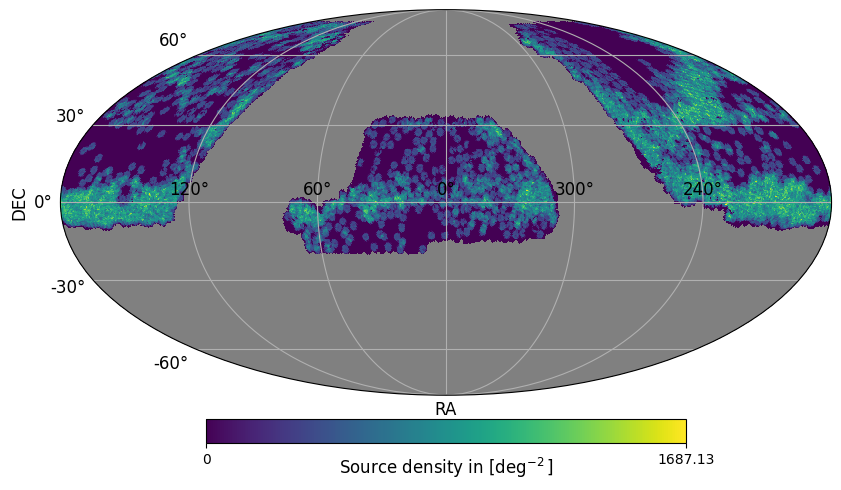

In [6]:
NSource_NGC = RADEC2NSource_Table(nside, NGC, nest=True)
NSource_SGC = RADEC2NSource_Table(nside, SGC, nest=True)
NSource_NGC_px, NSource_SGC_px = NSource_NGC/area_deg2, NSource_SGC/area_deg2
NSource_BGS_px = hp.ma(NSource_NGC_px+NSource_SGC_px)

df = DR1[[col_ipix, 'FRACCOV']].to_pandas() # Taking olnly useful columns
df['is_masked'] = DR1['FRACCOV'].mask
final_status = df.groupby(col_ipix)['is_masked'].all() #True if all rows for a pixel are masked
mask = np.array(final_status)
NSource_BGS_px.mask = mask

map = NSource_BGS_px.copy()
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True)
plt.xlabel("RA")
plt.ylabel("DEC");

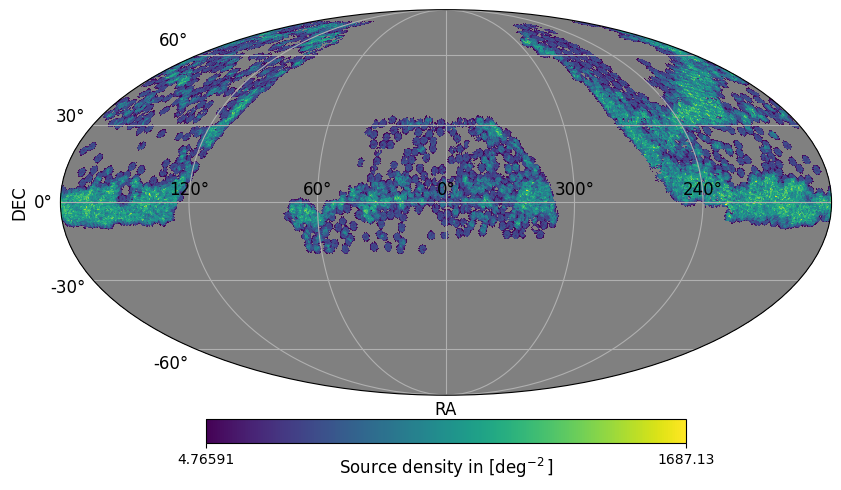

In [7]:
NSource_BGS_px_masked = hp.ma(NSource_NGC_px+NSource_SGC_px, badval=0)
map = NSource_BGS_px_masked.copy()
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True)
plt.xlabel("RA")
plt.ylabel("DEC");

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: divide by zero encountered in divide
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.712e+07 (χ²/ndof = 87.1) │              Nfcn = 566              │
│ EDM = 2.29e-06 (Goal: 0.0002)    │           time = 17.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  205.65   │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 1 │ A    │ 634.2e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │    0    │    1    │       │
│ 2 │ ra   │  229.90   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -50.72   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.09   │   0.09    │  -0.7e-3  │  0.7e-3   │   -0.07   │   0.07    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │   0.0076  26.2e-6   -0.001  -0.0025 │
│   A │  26.2e-6 4.44e-07   0.8e-6 -11.0e-6 │
│  ra │   -0.001   0.8e-6  0.00492   0.0013 │
│ dec │  -0.0025 -11.0e-6   0.0013  0.00278 │
└─────┴─────────────────────────────────────┘

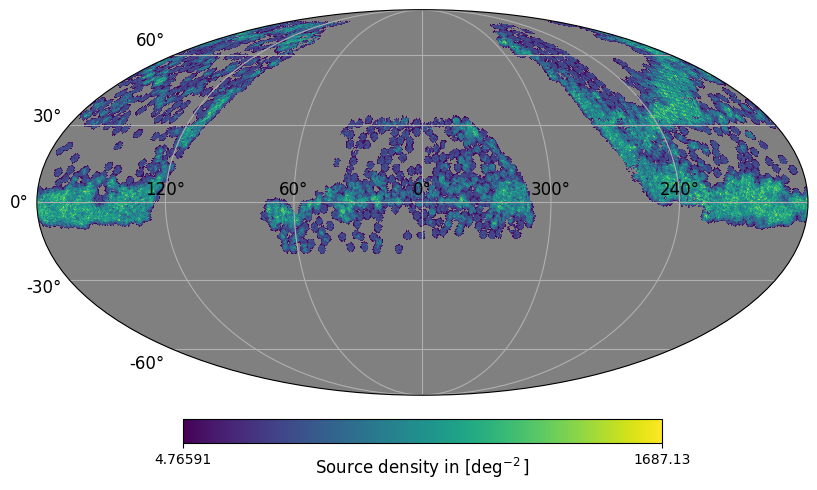

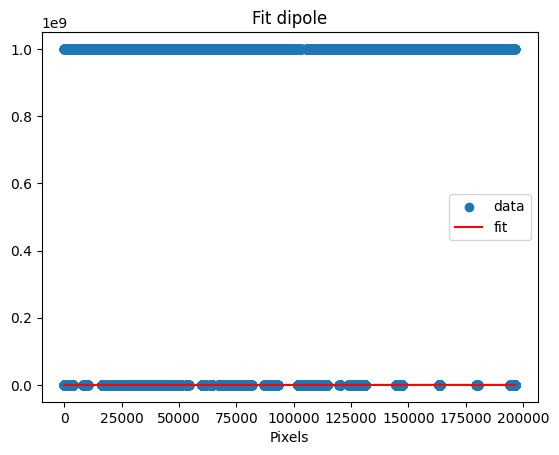

In [8]:
map = NSource_BGS_px_masked.copy()
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True)

mask = map.mask
mask = ~mask
weights = mask.astype(float)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map.filled(1e9), init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights)
m

## FRACCOV cut

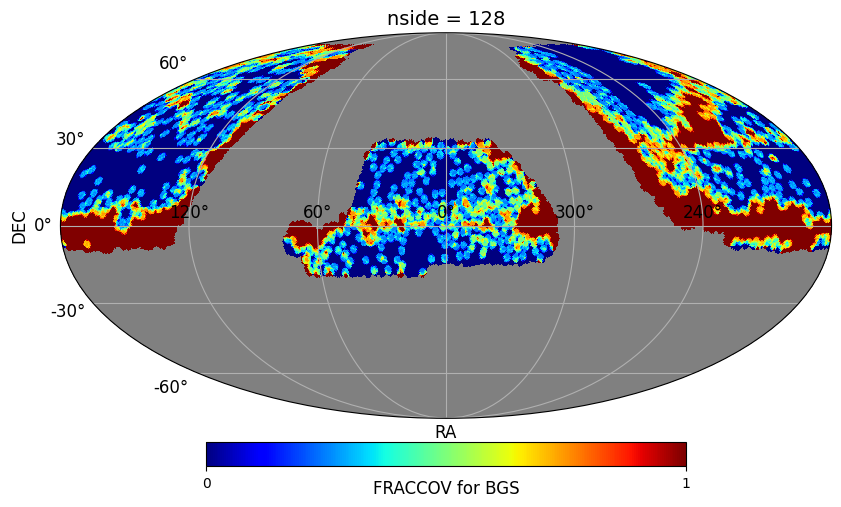

In [9]:
FRACCUT = df.groupby(col_ipix)['FRACCOV'].mean()
hp.projview(np.array(FRACCUT), unit="FRACCOV for BGS", title=f"nside = {nside}", nest=True, graticule=True, graticule_labels=True, cmap='jet')
plt.xlabel("RA")
plt.ylabel("DEC");

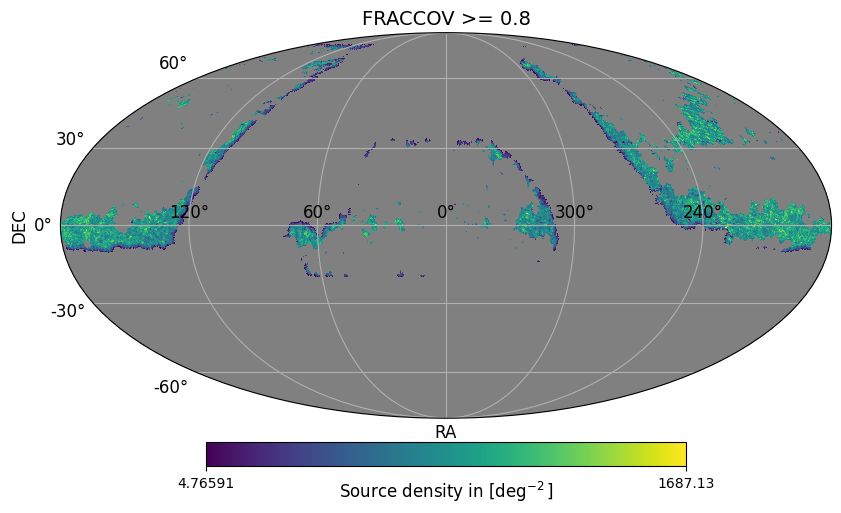

In [10]:
def get_cut(data, cut_mask, invert=False):
    sel = data.copy()
    if invert: cut_mask = ~cut_mask
    sel.mask = cut_mask | sel.mask
    return sel


def cut_FracCov(data, frac_min, FRACCOV=DR1['FRACCOV'], invert=False):
    mask = FRACCOV >= frac_min #values to keep are True
    return get_cut(data, ~mask, invert)


frac_min = 0.8
NSource_sel = cut_FracCov(NSource_BGS_px_masked, frac_min, FRACCUT)
map = NSource_sel
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True, title=f'FRACCOV >= {frac_min}')
plt.xlabel("RA")
plt.ylabel("DEC");

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: divide by zero encountered in divide
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.206e+06 (χ²/ndof = 31.6) │              Nfcn = 721              │
│ EDM = 3.07e-07 (Goal: 0.0002)    │           time = 23.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  412.44   │   0.19    │   -0.19    │    0.19    │    0    │         │       │
│ 1 │ A    │ 370.1e-3  │  0.9e-3   │  -0.9e-3   │   0.9e-3   │    0    │    1    │       │
│ 2 │ ra   │    11     │    330    │    -11     │    349     │    0    │   360   │       │
│ 3 │ dec  │-89.999999999995│0.000059855593│-0.000000000005│0.000064025183│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.19   │   0.19    │  -0.9e-3  │  0.9e-3   │    -11    │    349    │  -5e-12   │64025183e-12│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │               M               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│   M │          0.0362         76.8e-6            0.00     -5.0886e-12 │
│   A │         76.8e-6        8.25e-07         33.9e-6       -50.7e-15 │
│  ra │            0.00         33.9e-6        1.58e+04 -859.2553327e-9 │
│ dec │     -5.0886e-12       -50.7e-15 -859.2553327e-9        1.28e-15 │
└─────┴─────────────────────────────────────────────────────────────────┘

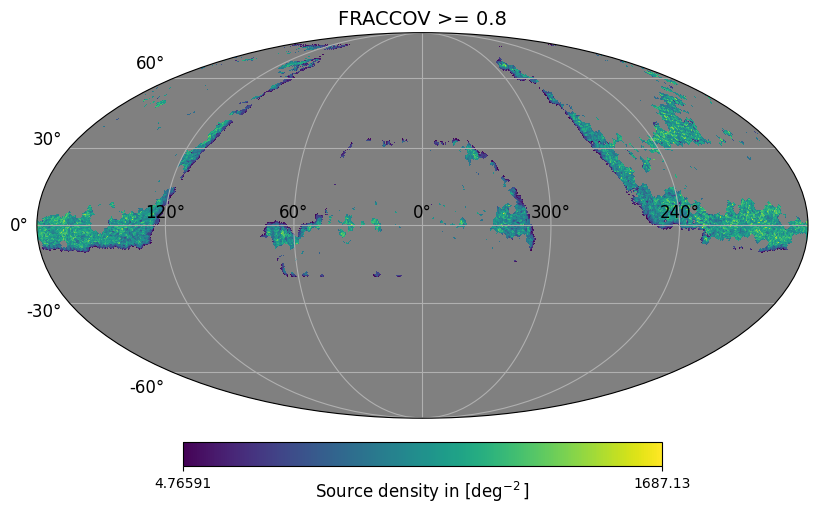

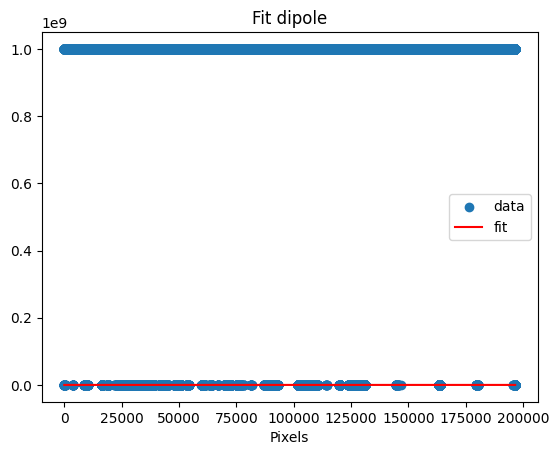

In [11]:
map = NSource_sel
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True, title=f'FRACCOV >= {frac_min}')

mask = map.mask
mask = ~mask
weights = mask.astype(float)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (2000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map.filled(1e9), init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.206e+06 (χ²/ndof = 31.6) │              Nfcn = 721              │
│ EDM = 3.07e-07 (Goal: 0.0002)    │           time = 22.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  412.44   │   0.19    │   -0.19    │    0.19    │    0    │         │       │
│ 1 │ A    │ 370.1e-3  │  0.9e-3   │  -0.9e-3   │   0.9e-3   │    0    │    1    │       │
│ 2 │ ra   │    11     │    330    │    -11     │    349     │    0    │   360   │       │
│ 3 │ dec  │-89.999999999995│0.000059855593│-0.000000000005│0.000064025183│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.19   │   0.19    │  -0.9e-3  │  0.9e-3   │    -11    │    349    │  -5e-12   │64025183e-12│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │               M               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│   M │          0.0362         76.8e-6            0.00     -5.0886e-12 │
│   A │         76.8e-6        8.25e-07         33.9e-6       -50.7e-15 │
│  ra │            0.00         33.9e-6        1.58e+04 -859.2553327e-9 │
│ dec │     -5.0886e-12       -50.7e-15 -859.2553327e-9        1.28e-15 │
└─────┴─────────────────────────────────────────────────────────────────┘

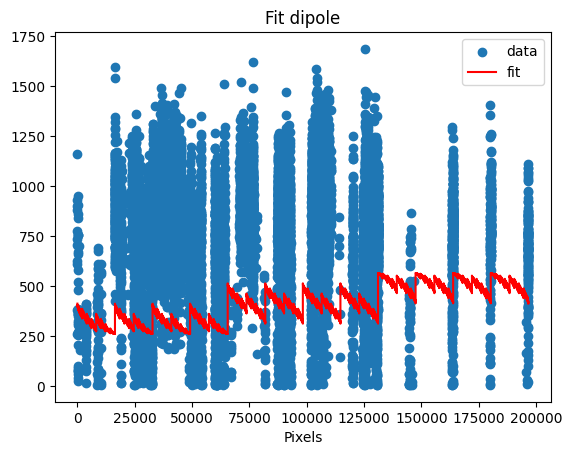

In [12]:
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

## Studying histogramms

Visible pixels for all without mask : 196608.0
Visible pixels for all with mask : 50142.0
Difference = 146466.0
Masked pixels for all with mask : 146466


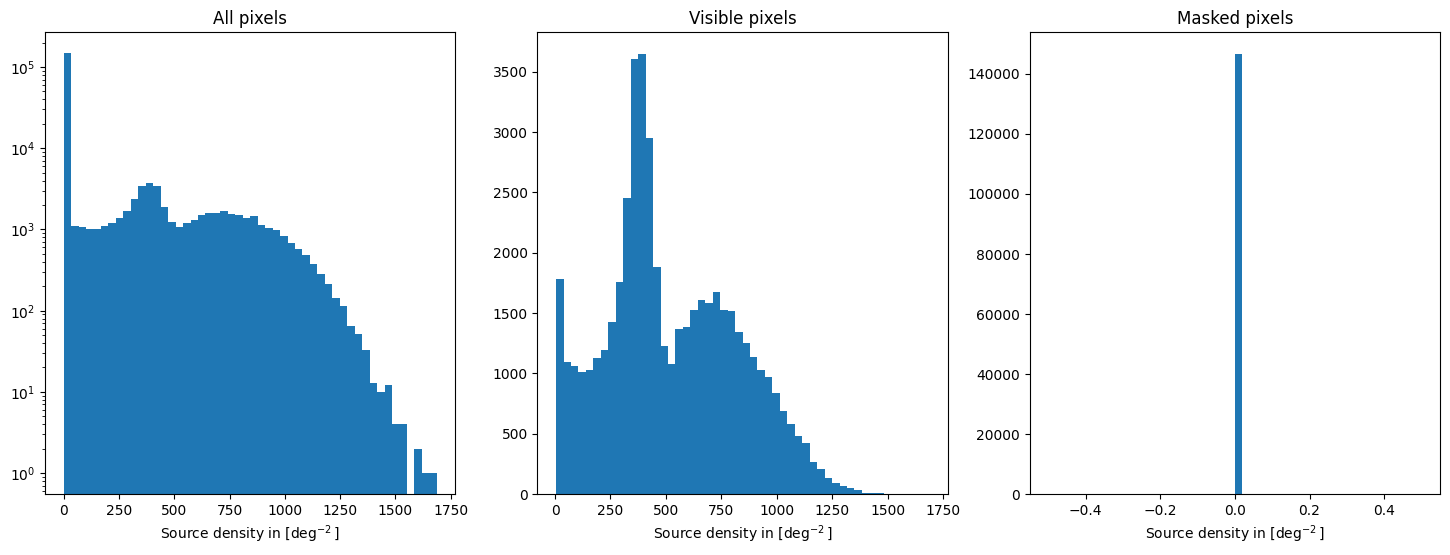

In [13]:
fig, ax = plt.subplots(1, 3, figsize=[18, 6])
var1, bins = get_hist(NSource_BGS_px_masked.data, xlabel="Source density in $[\deg^{-2}]$", title="All pixels", bins=50, log=True, figax=(fig, ax[0]))
var2, bins = get_hist(NSource_BGS_px_masked, xlabel="Source density in $[\deg^{-2}]$", title="Visible pixels", bins=50, log=False, figax=(fig, ax[1]))
get_hist(NSource_BGS_px_masked.data[NSource_BGS_px_masked.mask], xlabel="Source density in $[\deg^{-2}]$", title="Masked pixels", bins=50, log=False, figax=(fig, ax[2]))

print("Visible pixels for all without mask :", var1.sum())
print("Visible pixels for all with mask :", var2.sum())
print("Difference =", var1.sum() - var2.sum())
print("Masked pixels for all with mask :", np.count_nonzero(NSource_BGS_px_masked.mask))

Visible pixels for FRACCOV >= 0.8 without mask : 196608.0
Visible pixels for FRACCOV >= 0.8 with mask : 15260.0
Difference = 181348.0
Masked pixels for FRACCOV >= 0.8 with mask : 181348


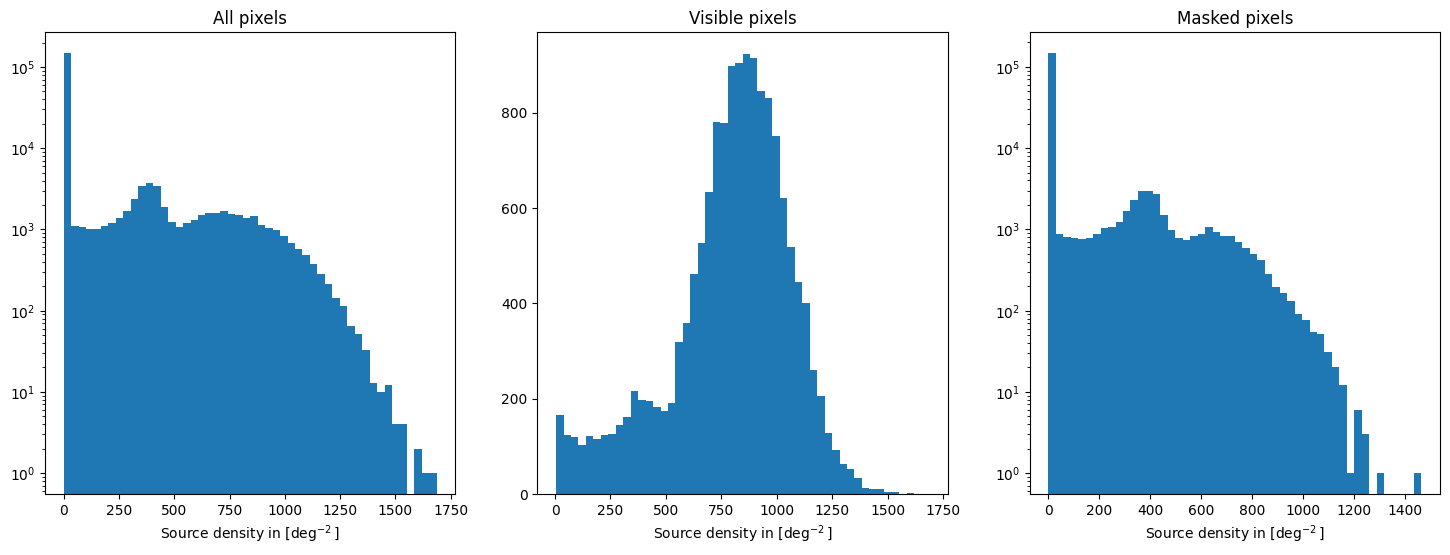

In [14]:
fig, ax = plt.subplots(1, 3, figsize=[18, 6])
var3, bins = get_hist(NSource_sel.data, xlabel="Source density in $[\deg^{-2}]$", title="All pixels", bins=50, log=True, figax=(fig, ax[0]))
var4, bins = get_hist(NSource_sel[~NSource_sel.mask], xlabel="Source density in $[\deg^{-2}]$", title="Visible pixels", bins=50, log=False, figax=(fig, ax[1]))
get_hist(NSource_sel.data[NSource_sel.mask], xlabel="Source density in $[\deg^{-2}]$", title="Masked pixels", bins=50, log=True, figax=(fig, ax[2]))

print(f"Visible pixels for FRACCOV >= {frac_min} without mask :", var3.sum())
print(f"Visible pixels for FRACCOV >= {frac_min} with mask :", var4.sum())
print("Difference =", var3.sum() - var4.sum())
print(f"Masked pixels for FRACCOV >= {frac_min} with mask :", np.count_nonzero(NSource_sel.mask))

Visible pixels for FRACCOV >= 0.8 without 0 masked : 16124.0
Visible pixels for FRACCOV >= 0.8 with 0 masked : 15260.0
Difference = 864.0
Masked pixels for FRACCOV >= 0.8 without 0 masked : 180484
Pixels of density = 0 for FRACCOV >= 0.8 : 864


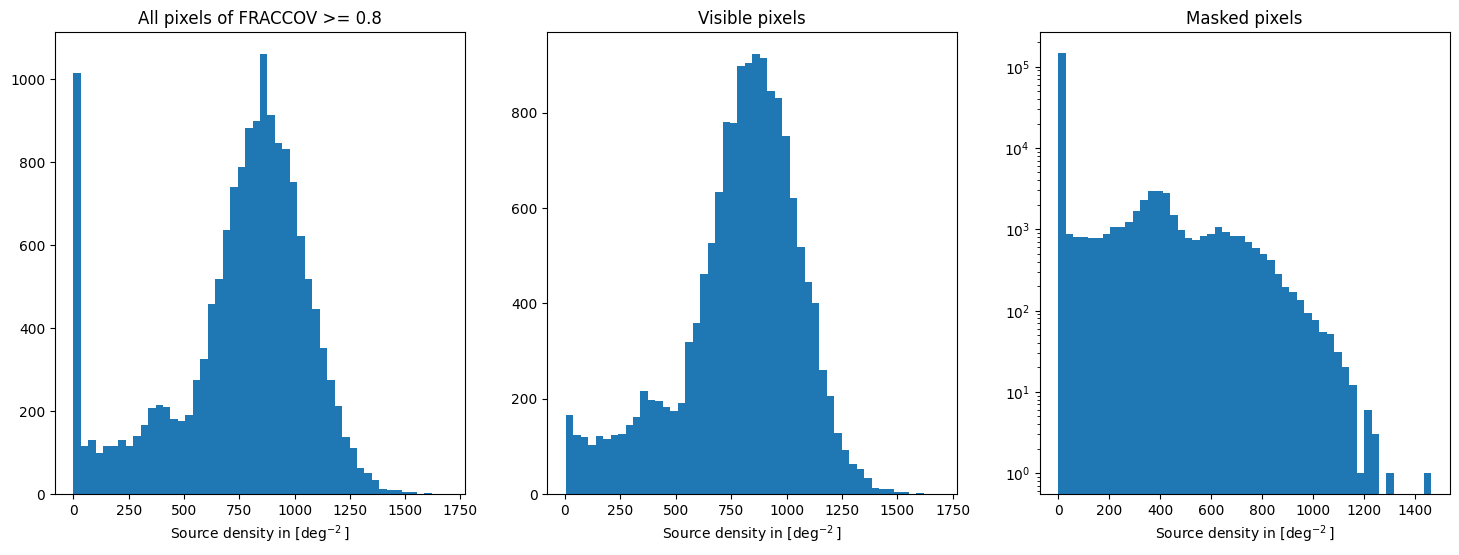

In [15]:
mask_fracMin = FRACCUT >= frac_min

fig, ax = plt.subplots(1, 3, figsize=[18, 6])
var5, bins = get_hist(NSource_sel.data[mask_fracMin], xlabel="Source density in $[\deg^{-2}]$", title=f"All pixels of FRACCOV >= {frac_min}", bins=50, log=False, figax=(fig, ax[0]))
var6, bins = get_hist(NSource_sel[mask_fracMin], xlabel="Source density in $[\deg^{-2}]$", title="Visible pixels", bins=50, log=False, figax=(fig, ax[1]))
get_hist(NSource_sel.data[~mask_fracMin], xlabel="Source density in $[\deg^{-2}]$", title="Masked pixels", bins=50, log=True, figax=(fig, ax[2]))

print(f"Visible pixels for FRACCOV >= {frac_min} without 0 masked :", var5.sum())
print(f"Visible pixels for FRACCOV >= {frac_min} with 0 masked :", var6.sum())
print("Difference =", var5.sum() - var6.sum())
print(f"Masked pixels for FRACCOV >= {frac_min} without 0 masked :", np.count_nonzero(~mask_fracMin))
print(f"Pixels of density = 0 for FRACCOV >= {frac_min} :", np.count_nonzero(NSource_sel.data[mask_fracMin] == 0))

In [16]:
print("Masked pixels for all with 0 masked :", np.count_nonzero(NSource_BGS_px_masked.mask))
print(f"Masked pixels for FRACCOV >= {frac_min} with 0 masked :", np.count_nonzero(NSource_sel.mask))
print(f"Masked pixels for FRACCOV >= {frac_min} with 0 not masked :", np.count_nonzero(~mask_fracMin))

print("\nVisible pixels for all with 0 masked :", np.count_nonzero(~NSource_BGS_px_masked.mask))
print(f"Visible pixels for FRACCOV >= {frac_min} with 0 masked :", np.count_nonzero(~NSource_sel.mask))

Masked pixels for all with 0 masked : 146466
Masked pixels for FRACCOV >= 0.8 with 0 masked : 181348
Masked pixels for FRACCOV >= 0.8 with 0 not masked : 180484

Visible pixels for all with 0 masked : 50142
Visible pixels for FRACCOV >= 0.8 with 0 masked : 15260


## Density count > min and FRACCOV > 0.9

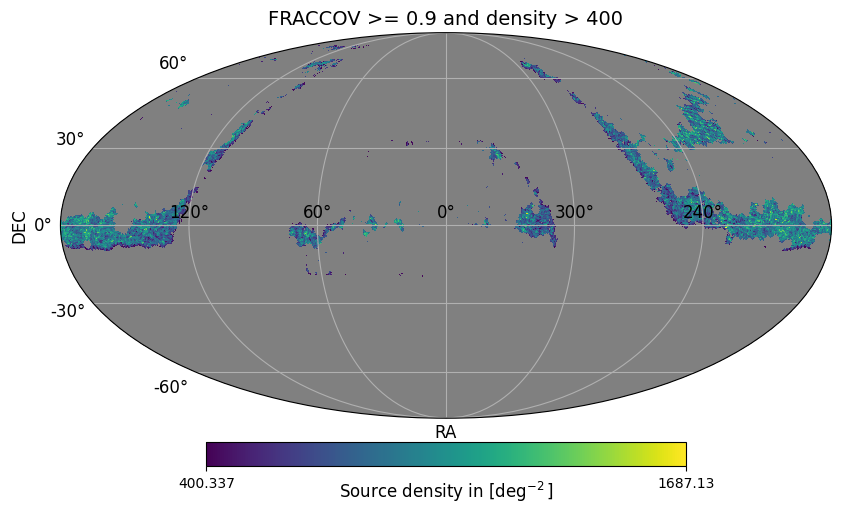

In [17]:
frac_min9 = 0.9
count_min = 400
mask_count = NSource_BGS_px_masked.data > count_min
NSource_sel2 = NSource_BGS_px_masked.copy()
NSource_sel2.mask[~mask_count] = True

NSource_sel2 = cut_FracCov(NSource_sel2, frac_min9, FRACCUT)
map = NSource_sel2
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True, title=f'FRACCOV >= {frac_min9} and density > {count_min}')
plt.xlabel("RA")
plt.ylabel("DEC");

Visible pixels for FRACCOV >= 0.9 without count mask : 15095.0
Visible pixels for FRACCOV >= 0.9 with count mask : 12633.0
Difference = 2462.0
Masked pixels for FRACCOV >= 0.9 with count mask : 183975
Pixels of density = 0 for FRACCOV >= 0.9 : 857


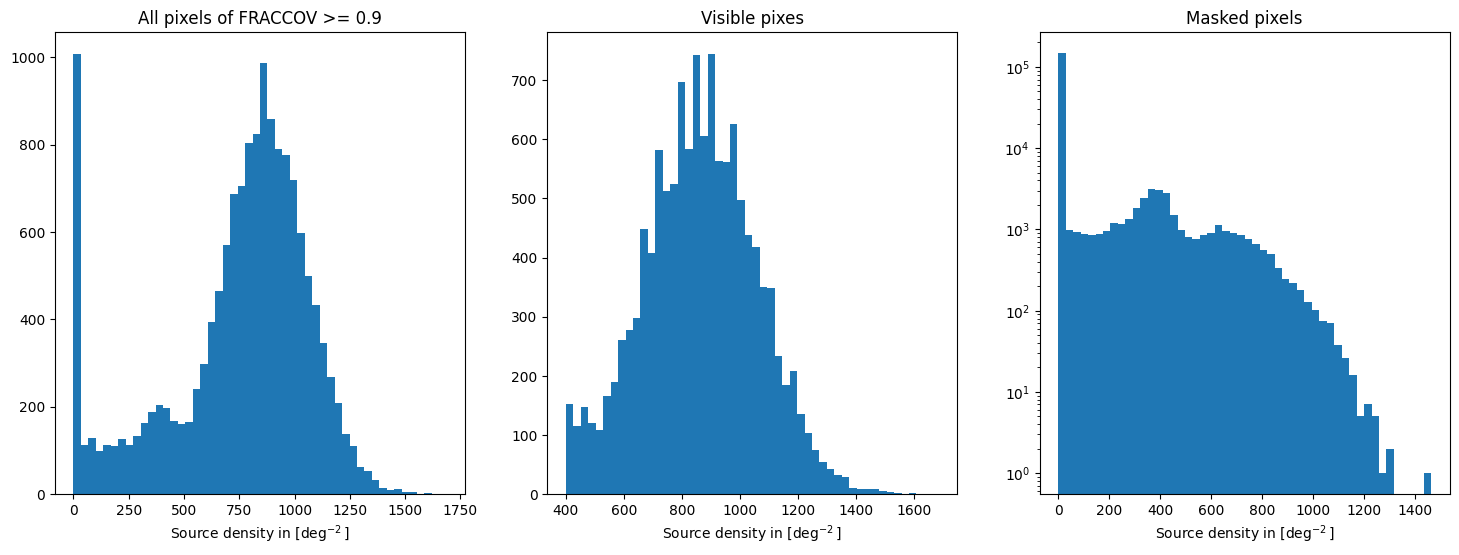

In [18]:
mask_fracMin9 = FRACCUT >= frac_min9

fig, ax = plt.subplots(1, 3, figsize=[18, 6])
var7, bins = get_hist(NSource_sel2.data[mask_fracMin9], xlabel="Source density in $[\deg^{-2}]$", title=f"All pixels of FRACCOV >= {frac_min9}", bins=50, log=False, figax=(fig, ax[0]))
var8, bins = get_hist(NSource_sel2[~NSource_sel2.mask], xlabel="Source density in $[\deg^{-2}]$", title="Visible pixes", bins=50, log=False, figax=(fig, ax[1]))
get_hist(NSource_sel2.data[NSource_sel2.mask], xlabel="Source density in $[\deg^{-2}]$", title="Masked pixels", bins=50, log=True, figax=(fig, ax[2]))

print(f"Visible pixels for FRACCOV >= {frac_min9} without count mask :", var7.sum())
print(f"Visible pixels for FRACCOV >= {frac_min9} with count mask :", var8.sum())
print("Difference =", var7.sum() - var8.sum())
print(f"Masked pixels for FRACCOV >= {frac_min9} with count mask :", np.count_nonzero(NSource_sel2.mask))
print(f"Pixels of density = 0 for FRACCOV >= {frac_min9} :", np.count_nonzero(NSource_sel2.data[mask_fracMin9] == 0))